In [80]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [81]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
FEATURES_TO_CONSIDER = [0, 1, 15, 16]

Z_DIM = 128
TRAJECTORY_NUM_ANCHORS = 200


In [82]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [83]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.444791218784125, 24.80997496713379)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.43it/s]


In [84]:
x = dataset['observations']
coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


def normalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
    dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
    return dataset

def denormalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] / 20) + 0.5) * (coord_0_max - coord_0_min) + coord_0_min
    dataset[..., 1] = ((dataset[..., 1] / 20) + 0.5) * (coord_1_max - coord_1_min) + coord_1_min
    return dataset

In [85]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])
dataset_goals = normalize_dataset_coords(dataset_goals)



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)



num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

# Trajectory encoder:

In [86]:

class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w

In [87]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [88]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.state_predict = nn.Sequential(
            nn.Linear(TRAJECTORY_NUM_ANCHORS + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, self.obs_len),
        )

        
        self.positional_encoding = PositionalEncoding(d_model=reward_pairs_emb_dim, dropout=0.1, max_len=TRAJECTORY_NUM_ANCHORS)



    def get_transformer_encoding(self, states, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
                
        x = self.positional_encoding(state_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, states_index): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states_index.shape[1], 1)        
        
        states_index = F.one_hot(states_index, num_classes=TRAJECTORY_NUM_ANCHORS)
        
        w_and_obs = torch.concatenate([z_expand, states_index], axis=-1)
        
        state_pred = self.state_predict(w_and_obs)
    
        return state_pred # [batch, reward_pairs]    

In [89]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, buffer):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        
        self.buffer = buffer
                
        self.std = 1
        
        self.len_params = Z_DIM
        
        
        self.resampling_weights = None
        self.trajectories_weights = None
        
        self.pre_computed_zs = None
    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_importance_sampling_indices(self, N, weights):
        indices = torch.multinomial(weights, N, replacement=True)
        return indices
    
    
    def get_training_data(self, batch_size, num_anchors, num_states, min_trajectory_size=50, max_trajectory_size=1000, trajectories_idx=None, offset=0):

        assert num_anchors < num_states
        
        if trajectories_idx is not None:
            batch_size = len(trajectories_idx) 

        obs_dim = self.obs_dim
        
        all_states = torch.zeros((batch_size, num_states, obs_dim), dtype=torch.float32)
        anchors = torch.zeros((batch_size, num_anchors, obs_dim), dtype=torch.float32)
        next_states = torch.zeros((batch_size, num_anchors, obs_dim), dtype=torch.float32)
        
        
        buffer = self.buffer
        assert buffer is not None
        
        num_trajectories, trajectory_length = buffer.shape[0], buffer.shape[1]
        

        if trajectories_idx is None:
            trajectory_idx = self.get_importance_sampling_indices(batch_size, self.trajectories_weights)


        for i in range(batch_size):
            
            sub_trajectory_size = torch.randint(min_trajectory_size, max_trajectory_size, (1,)).item()
            start_idx = torch.randint(0, trajectory_length - sub_trajectory_size + 1 - offset, (1,)).item()
            end_idx = start_idx + sub_trajectory_size
                     
            sub_trajectory_anchors_idx = torch.linspace(start_idx, end_idx-2, steps=num_anchors).long()    
            anchors[i] = buffer[trajectory_idx[i], sub_trajectory_anchors_idx]
            next_states[i] = buffer[trajectory_idx[i], sub_trajectory_anchors_idx + 1]
            
        
        all_states[:, :num_anchors, :] = anchors
        

        
        # Get non anchors
        num_non_anchors = num_states - num_anchors
        random_states_idx = self.get_importance_sampling_indices(num_non_anchors*batch_size, self.resampling_weights)
        trajectories_idx = random_states_idx // trajectory_length
        states_idx = random_states_idx % trajectory_length
        non_anchors = buffer[trajectories_idx, states_idx]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, 2)
        all_states[:, num_anchors:, :] = non_anchors
        
        
        pad_mask = torch.ones((batch_size, num_anchors), dtype=torch.bool)
        pad_mask[:, :num_anchors] = False
            
        state_in_trajectory = torch.zeros((batch_size, num_states), dtype=torch.float32)
        state_in_trajectory[:, :num_anchors] = 1        
        
        
        return (anchors, next_states, pad_mask), (all_states, state_in_trajectory), {
            'trajectories_idx': trajectories_idx.reshape(-1),
        }
    

        
    def train_step_VAE(self, batch_size, num_anchors, num_states, non_anchor_coef, min_trajectory_size, max_trajectory_size):
        self.fre_network.train()
        
        (anchors, next_states, pad_mask), (all_states, state_in_trajectory), info = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_states,
            min_trajectory_size=min_trajectory_size,
            max_trajectory_size=max_trajectory_size,
        )
        anchors = anchors.to(device)
        next_states = next_states.to(device).flatten(0, 1)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        state_in_trajectory = state_in_trajectory.to(device)
        
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        
        rabdom_states_idx = torch.randint(0, TRAJECTORY_NUM_ANCHORS, (batch_size, 50,), device=device, dtype=torch.long)
        # rabdom_states_idx = torch.linspace(0, TRAJECTORY_NUM_ANCHORS-1, 50, device=device, dtype=torch.long).unsqueeze(0).repeat(batch_size, 1)
        traj_indicies = torch.arange(0, batch_size).unsqueeze(1).repeat(1, 50)
        
        selected_anchors = anchors[traj_indicies.flatten(), rabdom_states_idx.flatten()].reshape(batch_size, 50, -1)
        
        state_pred = self.fre_network.get_reward_pred(w, rabdom_states_idx)
        
        
        pred_loss = (selected_anchors - state_pred).pow(2).sum(-1).mean()
        
        # inter_rewards_pred = self.fre_network.get_reward_pred(w, info['intermediate_anchors'].to(device))
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        # reward_pred_loss = ((rewards_pred[is_anchor] - rewards[is_anchor])**2).mean() + ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef



        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = (pred_loss) + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'pred_loss': pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info
        }
        
        
    
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, num_anchors:int, min_trajectory_size, max_trajectory_size):
        # assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, next_states, pad_mask), (all_states, state_in_trajectory), info = self.get_training_data(
            batch_size=batch_size, 
            num_anchors=num_anchors, 
            num_states=num_anchors+1,
            min_trajectory_size=min_trajectory_size,
            max_trajectory_size=max_trajectory_size
        )
        anchors = anchors.to(device)
        next_states = next_states.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, pad_mask)
        
        return eval_z, {'anchors': anchors.cpu(), 'pad_mask': pad_mask.cpu(), 'next_states': next_states.cpu(), 'get_training_data:info': info}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
    
    
    

In [90]:
fre_network = FRENetwork(obs_len=2)
fre_network.load_state_dict(torch.load('models/iql_trajectory_encoder_fre_network.pth'))

trajectory_encoder = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    buffer=dataset_trajectories[..., :2],
)


# reward_generator.new_states_buffer = torch.load('models/new_states_buffer_14.pth')['new_states_buffer']
# reward_generator.new_actions_buffer = torch.load('models/new_actions_buffer_14.pth')['new_actions_buffer']


resampler = RNDResampling()
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
# resampler_losses = resampler.fit(rnd_dataset, epochs=5000)
# resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.2)
# trajectory_encoder.resampling_weights = resampling_weights
# trajectory_encoder.trajectories_weights = resampling_weights.reshape(-1, TRAJECTORY_LEN).sum(dim=1)

vae_loss, vae_kl_loss = [], []

/tmp/ipykernel_33403/76047236.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fre_network.load_state_dict(torch.load('models/iql_trajectory_encoder_fre_network.pth'))


In [91]:
# for i in tqdm(range(20000), desc='VAE training', leave=False):
#     vae_loss_dict = trajectory_encoder.train_step_VAE(
#         batch_size=64,
#         num_anchors=TRAJECTORY_NUM_ANCHORS,
#         num_states=800,
#         non_anchor_coef=1.,
#         min_trajectory_size=1000,
#         max_trajectory_size=1001,
#     )
#     vae_loss.append(vae_loss_dict['loss'])
#     vae_kl_loss.append(vae_loss_dict['kl_loss'])
    
#     if i % 100 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#         axs[0].plot(vae_loss)
#         axs[0].set_ylim([0, 2])
#         axs[1].plot(vae_kl_loss)
#         axs[1].set_ylim([0, 5])
#         plt.show()
        
#         # eval_num_envs = 4
#         # eval_z, info = trajectory_encoder.get_z_from_random_anchors(eval_num_envs, num_anchors=200, min_trajectory_size=1000, max_trajectory_size=1001)
#         # eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)
#         # base_z = info['base_z']

#         # anchors, anchors_rewards, pad_mask = info['anchors'], info['anchors_rewards'], info['pad_mask']
#         # fig, axs = visualize_rewards_and_trajectories(eval_z, trajectory_encoder, ancho   rs, anchors_rewards, pad_mask)
#         # for i in range(eval_num_envs): axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c=anchors_rewards[i], s=40)
#         # fig.show()
        
#         # plt.show()

In [92]:
# torch.save(fre_network.state_dict(), 'models/ddpg_trajectory_encoder_fre_network.pth')

# DDPG:

In [249]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -1, 1)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )

In [250]:
class DDPG(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(DDPG, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[512, 512, 512, 512])
        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[512, 512, 512, 512])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    
    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    

def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [251]:
def trajectory_value_function(states, target_trajectory):
    assert target_trajectory.dim() == 2 # (num_anchors, obs_dim)
    assert states.dim() == 2     # (num_states, obs_dim)
    
    
    distances = (states[:, None] - target_trajectory[None, :]).pow(2).sum(dim=-1)
        
    min_info = distances.min(dim=-1)
    min_distances, clostest_anchor = min_info.values, min_info.indices

    # return clostest_anchor[:states.shape[0]]
    
    # r = (min_distances < 3) * clostest_anchor
    r = clostest_anchor
    
    return r / 1000


In [252]:
def get_ddpg_training_data(batch_size, num_states, num_trajectory_states):

    # batch_size = 16
    # num_trajectory_states = 200
    # num_states = 1024

    # trajectory_indicies = trajectory_encoder.get_importance_sampling_indices(batch_size, trajectory_encoder.trajectories_weights)
    trajectory_indicies = torch.randint(0, dataset_trajectories.shape[0], (batch_size,))


    states = torch.zeros((batch_size, num_states, obs_dim))
    next_states = torch.zeros((batch_size, num_states, obs_dim))
    actions = torch.zeros((batch_size, num_states, 8))
    masks = torch.zeros((batch_size, num_states, 1))
    rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    next_values = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    traj_anchors = torch.zeros((batch_size, num_trajectory_states, 2))


    for i, trajectory_idx in enumerate(trajectory_indicies):

        target_trajectory = dataset_trajectories[trajectory_idx, :, :2]

        t = dataset_trajectories[trajectory_idx, ::100, :2]
        x = dataset_trajectories[:, ::100, :2].reshape(-1, 2)
        distance_to_trajectory = (x[:, None] - t[None]).pow(2).sum(-1).reshape(dataset_trajectories.shape[0], -1, t.shape[0]).min(dim=-1).values.sum(dim=-1)
        
        near_trajectories_indicices = torch.nonzero(distance_to_trajectory < 20).flatten()
        
        near_trajectories = dataset_trajectories[near_trajectories_indicices]

        ti = torch.randint(0, near_trajectories.shape[0], (num_states,))
        si = torch.randint(0, near_trajectories.shape[1]-1, (num_states,))
        
        states[i] = near_trajectories[ti, si]
        next_states[i] = near_trajectories[ti, si+1]
        actions[i] = dataset_actions[near_trajectories_indicices][ti, si]
        masks[i] = ~dataset_timeouts[near_trajectories_indicices][ti, si+1].unsqueeze(-1)
        
        traj_anchors[i] = target_trajectory[torch.linspace(0, target_trajectory.shape[0]-1, num_trajectory_states, dtype=torch.long)]
        
        next_values[i] = trajectory_value_function(next_states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
        

    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'rewards': rewards.to(device),
        'traj_anchors': traj_anchors.to(device),
        'masks': masks.to(device),
        'next_values': next_values.to(device)
    }

In [253]:
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

# i = 0
# plt.scatter(states[i, :, 0], states[i, :, 1], c=rewards[i], s=10, vmin=-1, vmax=1)
# plt.scatter(traj_anchors[i, :, 0], traj_anchors[i, :, 1], s=10, c='red')

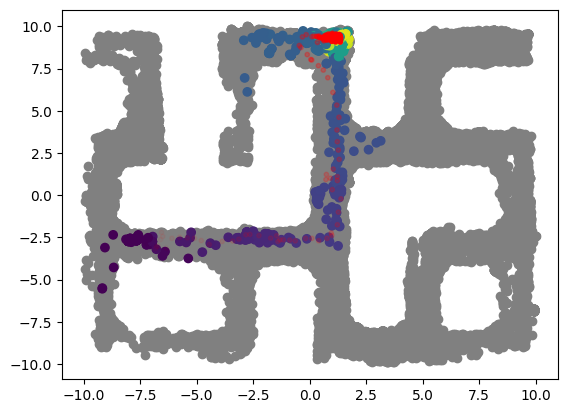

In [254]:
batch = get_ddpg_training_data(batch_size=16, num_states=1024, num_trajectory_states=200)

plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

i = 15
plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=batch['next_values'][i, :, 0].cpu())
plt.scatter(batch['traj_anchors'][i, :, 0].cpu(), batch['traj_anchors'][i, :, 1].cpu(), c='red', s=10, alpha=np.linspace(0, 1, 200))

In [137]:
# _ = plt.hist(v.flatten().cpu().detach(), bins=100)

In [330]:
ddpg_agent = DDPG(state_dim=obs_dim, action_dim=8).to(device)
ddpg_agent.critic.load_state_dict(torch.load('models/ddpg_critic.pth'))


actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

/tmp/ipykernel_33403/3912940538.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ddpg_agent.critic.load_state_dict(torch.load('models/ddpg_critic.pth'))


In [331]:
# config = {
#     'discount': 0.99,
#     'tau': 0.001,
# }


# for timestep in tqdm(range(4_000)):


#     # batch = get_ddpg_training_data(
#     #     batch_size=16, min_trajectory_size=1000, max_trajectory_size=1001, num_anchors_states=200,
#     #     num_trajectory_states=200, num_random_states=200
#     # )
    
#     batch = get_ddpg_training_data(batch_size=32, num_states=512, num_trajectory_states=200)
    
#     # break
    
    
#     with torch.no_grad():
#         w_mean, _ = trajectory_encoder.fre_network.get_transformer_encoding(batch['traj_anchors'], pad_mask=None)


#     # Implicit Q-Learning
    
    
#     w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    

#     # Critic Loss. Update Q = r #############################
    
#     targets = batch['next_values']

#     q, _ = ddpg_agent.get_critic(w_target, batch['states'], batch['actions'])
#     q_loss = (q - targets).pow(2)
#     q_loss = q_loss.mean()
    
#     ddpg_agent.critic.zero_grad()
#     q_loss.backward()
#     ddpg_agent.critic_optim.step()


#     value_info = {
#         'q_loss': q_loss.detach(),
#         'q': q.detach(),
#     }

#     ########################################################################################
    
#     # loss = value_loss + actor_loss
    
#     # optimizer.zero_grad()
#     # loss.backward()
#     # optimizer.step()

    
    
    
#     q_losses.append(q_loss.item())
    
#     if timestep % 100 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 1, figsize=(6, 5))

#         # axs.plot(smooth_and_downsample(q_losses))
#         axs.plot(q_losses)
#         axs.set_ylim(0,max(q_losses[-100:]))
#         # axs.set_ylim(0,0.1)
#         axs.set_title("Q Loss")

#         plt.show()
        
#     break

In [332]:
# torch.save(ddpg_agent.critic.state_dict(), 'models/ddpg_critic.pth')

In [333]:
# i = 20

# plt.scatter(dataset_trajectories[:, ::10, 0].cpu(), dataset_trajectories[:, ::10, 1].cpu(), c='gray')

# plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=q[i].cpu().detach())
# # plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=batch['rewards'][i].cpu(), vmin=-2, vmax=2)



# plt.scatter(batch['traj_anchors'][i, :, 0].cpu(), batch['traj_anchors'][i, :, 1].cpu(), c='red', s=torch.linspace(2, 100, 200))



In [334]:
# torch.save(ddpg_agent.state_dict(), 'models/ddpg_agent.pth')

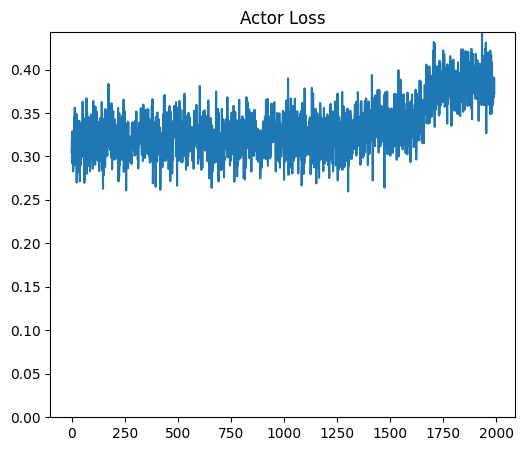

  3%|▎         | 108/4000 [00:13<08:00,  8.10it/s]


KeyboardInterrupt: 

In [367]:
for timestep in tqdm(range(4_000)):
    
    batch = get_ddpg_training_data(batch_size=32, num_states=512, num_trajectory_states=200)    
    
    with torch.no_grad():
        w_mean, _ = trajectory_encoder.fre_network.get_transformer_encoding(batch['traj_anchors'], pad_mask=None)
    
    w_mean = w_mean.detach()
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
        
    
    dist = ddpg_agent.get_actor(w_target, batch['states'])
    # action = dist.loc
    # action = dist.sample()
    action = dist.loc + torch.normal(0, 1, dist.loc.shape, device=device) * dist.stddev
    # noise = torch.normal(0, 0.1, action.shape).to(device)
    q, _ = ddpg_agent.get_critic(w_target, batch['states'], action)
    actor_loss = - q.mean()
    
    ddpg_agent.actor.zero_grad()
    actor_loss.backward()
    ddpg_agent.actor_optim.step()
    
    actor_losses.append(q.mean().item())
    
    if timestep % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))

        # axs.plot(smooth_and_downsample(q_losses))
        axs.plot(actor_losses)
        axs.set_ylim(0,max(actor_losses[-100:]))
        # axs.set_ylim(0,0.1)
        axs.set_title("Actor Loss")

        plt.show()
        
    # break

---

In [366]:
action.clip(-1, 1)

tensor([[[-1.0000,  1.0000,  1.0000,  ..., -1.0000,  1.0000,  1.0000],
         [ 0.2763,  1.0000,  1.0000,  ..., -1.0000,  1.0000,  1.0000],
         [ 1.0000,  1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
         ...,
         [ 1.0000,  1.0000,  1.0000,  ...,  1.0000, -1.0000,  1.0000],
         [-1.0000,  1.0000, -1.0000,  ...,  1.0000,  1.0000, -1.0000],
         [ 1.0000,  1.0000, -1.0000,  ..., -1.0000, -1.0000,  1.0000]],

        [[-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000, -0.1930],
         [-0.7582, -1.0000, -1.0000,  ..., -1.0000,  1.0000,  1.0000],
         [ 1.0000, -1.0000, -1.0000,  ..., -0.6220,  1.0000,  1.0000],
         ...,
         [ 1.0000,  1.0000, -1.0000,  ...,  1.0000, -1.0000,  1.0000],
         [ 0.5432, -1.0000,  1.0000,  ..., -1.0000,  1.0000,  1.0000],
         [ 1.0000, -1.0000,  1.0000,  ...,  1.0000,  1.0000, -1.0000]],

        [[-1.0000,  1.0000,  1.0000,  ..., -1.0000, -1.0000,  1.0000],
         [ 1.0000, -1.0000,  1.0000,  ...,  1

In [368]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()



def reset_to_state(env, state):
    env.sim.reset()
    qpos = env.init_qpos
    qpos[:] = np.array(state[:15]).astype(env.observation_space.dtype)
    qvel = env.init_qvel
    qvel[:] = np.array(state[15:]).astype(env.observation_space.dtype)
    
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()



In [369]:
batch = get_ddpg_training_data(batch_size=1, num_states=512, num_trajectory_states=200)

Target Goal:  (32.51043933262694, 25.11904092958589)


100%|██████████| 2000/2000 [00:01<00:00, 1215.56it/s]


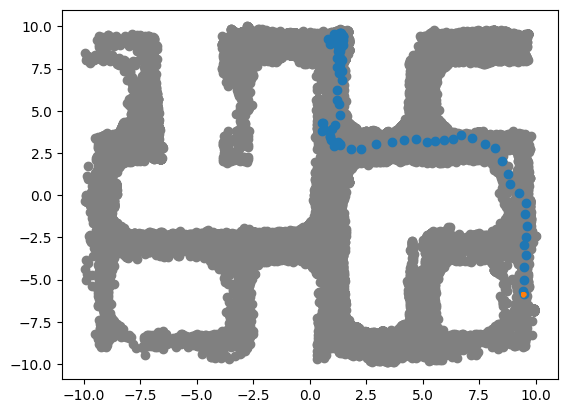

In [375]:
# batch = get_ddpg_training_data(
#     batch_size=1, min_trajectory_size=1000, max_trajectory_size=1001, num_anchors_states=200,
#     num_trajectory_states=400, num_random_states=400
# )

# batch = get_ddpg_training_data(batch_size=1, num_states=512, num_trajectory_states=200)



state = env.reset()
location = np.array(denormalize_dataset_coords(batch['traj_anchors'][0, 0, :2].cpu()))
state = reset_to_location(env, location)
# state = reset_to_state(env, denormalize_dataset_coords(batch['states'][0, 0, :].cpu()))
state = normalize_dataset_coords(state)[..., :STATE_DIM]




with torch.no_grad():
    w_mean, _ = trajectory_encoder.fre_network.get_transformer_encoding(batch['traj_anchors'], pad_mask=None)
    w_mean = w_mean.unsqueeze(1)




produced_trajectory = []

for _ in tqdm(range(2000)):
    tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
    
    with torch.no_grad():
        dist = ddpg_agent.get_actor(w_mean, tensor_state)
        pred_action = dist.loc.cpu()
        # pred_action = dist.sample().cpu()
        # print(pred_action.shape)
        action = pred_action[0, 0]
        action = np.array(action)
        
    new_state, _, _, _ = env.step(action)

    
    produced_trajectory.append(state)

    state = new_state
    state = normalize_dataset_coords(state)[..., :STATE_DIM]
    
    
produced_trajectory = np.stack(produced_trajectory)



plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')


# x = dataset_trajectories[trajectory_idx]
# print(x.any())
# plt.scatter(x[:, 0], x[:, 1])
# plt.scatter(anchors[0, ::5, 0].cpu(), anchors[0, ::5, 1].cpu(), c='red')
plt.scatter(batch['traj_anchors'][..., 0].cpu(), batch['traj_anchors'][..., 1].cpu())
plt.scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], s=5)

In [376]:
dist.scale

tensor([[[7.3891, 7.3891, 7.3891, 0.4943, 2.8673, 7.3891, 7.3891, 7.3891]]],
       device='cuda:0')

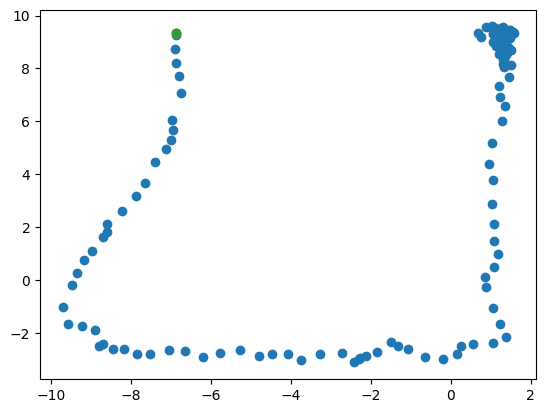

In [ ]:
plt.scatter(batch['traj_anchors'][..., 0].cpu(), batch['traj_anchors'][..., 1].cpu())
plt.scatter(batch['traj_anchors'][0, 0, 0].cpu(), batch['traj_anchors'][0, 0, 1].cpu())

# plt.scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], s=10)
plt.scatter(state[0], state[1])